### AI Project : Smart School 

Il s'agit du fichier EDA - Exploratory Data Analysis

C’est la phase où on explore le dataset avant de faire du machine learning
On ne construit pas encore le modèle, on essaie de comprendre les données.

   id  age   genre              diplôme  heures_etude  assiduité_classe  \
0   0   21    male     Computer Science          7.91              98.8   
1   1   18  female                  Law          4.95              94.8   
2   2   20  female     Computer Science          4.68              92.6   
3   3   19    male     Computer Science          2.00              49.5   
4   4   23  female  Business Management          7.65              86.9   

  accès_internet  heures_sommeil qualité_sommeil  méthode_etude  \
0            NaN             4.9         average  online videos   
1            yes             4.7            poor     self-study   
2            NaN             5.8            poor       coaching   
3            yes             8.3         average    group study   
4            yes             9.6            good     self-study   

  évaluation_établissement difficulté_examen  score_examen  heures_fête  \
0                      low              easy         75.02            5

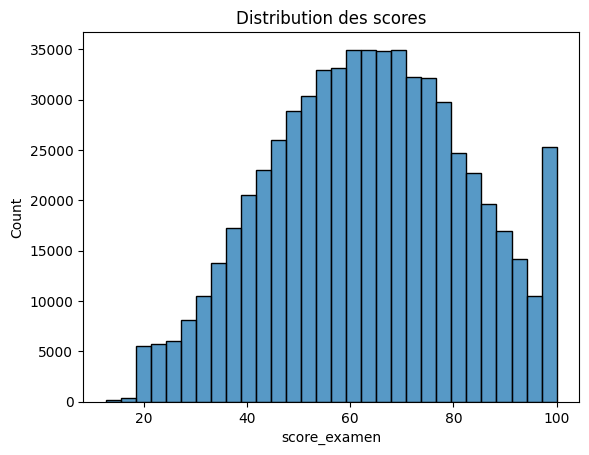

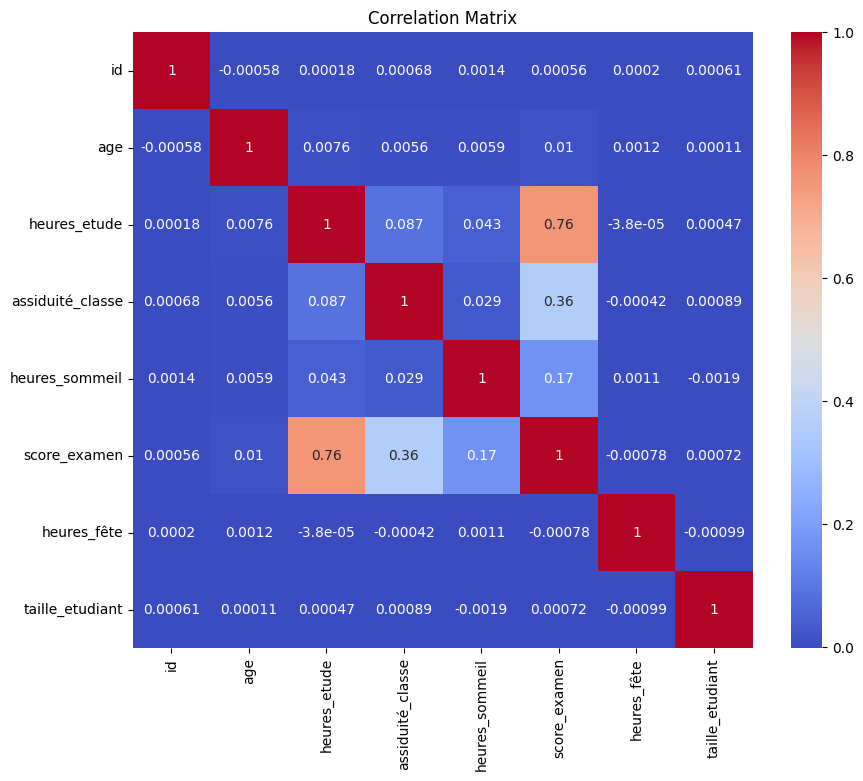

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# En notebook, __file__ n'existe pas. On construit le chemin relativement au dossier courant.
csv_path = Path("student_dataset") / "student_failure" / "train.csv"
df = pd.read_csv(csv_path)

print(df.head())
print(df.info())
print(df.describe())

# Distribution du score
plt.figure()
sns.histplot(df["score_examen"], bins=30)
plt.title("Distribution des scores")
plt.show()

# Corrélation
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

##  Encodage des variables catégorielles - Encoding 
Permet de convertir du texte en nombres. Dans notre dataset par exemple ça permet de faire : 
Male = 1 et Female = 0

drop_first=True permet d'éviter la multicolinéarité en supprimant une des catégories après l'encodage

Permet d'éviter la redondance 

In [4]:
df = pd.get_dummies(df, drop_first=True)

## Scaling 
Sans ça, les échelles sont très différentes 

Avec le scaling, toute les variables deviennent comparables 

Toute les variables ont le même poids et le modèle peut mieux apprendre. 

In [5]:
scaler = StandardScaler()
X = df.drop("score_examen", axis=1)
y = df["score_examen"]

## Création du modèle 

In [ ]:
import numpy as np

baseline = np.mean(y)
print("Baseline RMSE:", np.sqrt(np.mean((y - baseline)**2)))

Baseline RMSE: 18.9508245624742


<!-- ## Random Forest  -->

In [ ]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error

# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

# model = RandomForestRegressor()
# model.fit(X_train, y_train)

# pred = model.predict(X_test)

# rmse = mean_squared_error(y_test, pred, squared=False)
# print("RMSE:", rmse)